0. Title

1. Set up& Reproducibility

In [ ]:
import os, re, json, math, random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

pd.set_option("display.max_colwidth", 120)

2.1 Data config

In [3]:
DATA_PATH = "/mnt/data/dataset_A_news_full_10500.csv"

TEXT_COL = "title"
LABEL_COL = "classes_str"

CATEGORICAL_COLS_CANDIDATES = ["source", "day_of_week", "month", "year", "quarter", "is_weekend"]
NUMERIC_COLS_CANDIDATES = ["number_of_characters_title", "number_of_words_title"]

TEST_SIZE = 0.2

2.2 Schema / Columns

In [4]:
df = pd.read_csv(r"C:\Users\Kiraa\OneDrive\Desktop\dataset_A_news_full_10500.csv")
df.columns = df.columns.astype(str).str.strip()

need = {TEXT_COL, LABEL_COL}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found: {list(df.columns)}")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head(3))


Shape: (10500, 12)
Columns: ['title', 'link', 'date', 'source', 'number_of_characters_title', 'number_of_words_title', 'day_of_week', 'month', 'year', 'quarter', 'is_weekend', 'classes_str']


,title,link,date,source,number_of_characters_title,number_of_words_title,day_of_week,month,year,quarter,is_weekend,classes_str
0,"Google’s AI is the ‘worst’ for stealing content, says People CEO",https://news.google.com/rss/articles/CBMipgFBVV95cUxNY0lCNkcyS21vamMyM0UzWFFxdDV3dzZZQVlFNUZMY3ptR1owaGh6LVhGSURrMFk...,2025-09-11,Fortune,74,13,Thursday,September,2025,3,False,"Sentiment (Positive / Negative Feelings); Human Roles; Society, Ethics & Culture"
1,Powering the Next Wave of Enterprise Innovation: Mesh-AI Named OpenAI UK Services Partner,https://news.google.com/rss/articles/CBMitgFBVV95cUxOYlNnckMtdVR5Z2RRSnh5VlY5NURkRlN6VHlIRG9OM3AxZHRRNVFFMU9Fai1icXJ...,2025-09-11,Silicon Canals,106,16,Thursday,September,2025,3,False,"Creativity, Expression & Identity; Work, Jobs & Economy"
2,AI a ‘strategic necessity’ law lecturer says,https://news.google.com/rss/articles/CBMiiAFBVV95cUxNMTFybTAyLWZqRk83RlJyUm4yLWtCY2pjT29NY2tjM0FNdGNqcFJhajJ5RmtJSnV...,2025-09-11,qlsproctor.com.au,64,9,Thursday,September,2025,3,False,"Society, Ethics & Culture"


3.1 Label Quality Control(Noise&Consistency)

In [5]:
df = df.copy()

# 1) drop missing label/title
df = df.dropna(subset=[LABEL_COL]).copy()
df[TEXT_COL] = df[TEXT_COL].astype(str).fillna("").str.strip()
df[LABEL_COL] = df[LABEL_COL].astype(str).fillna("").str.strip()
df = df[df[TEXT_COL].astype(bool)]
df = df[df[LABEL_COL].astype(bool)]

# 2) deduplicate by text
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)

# 3) label distribution
vc = df[LABEL_COL].value_counts()
print("Rows after clean:", len(df))
print("Num classes:", df[LABEL_COL].nunique())
display(vc.head(15))

# 4) Rare label handling for stratified split
#    If a label appears only once, stratify may fail. We merge rare labels into OTHER_RARE for splitting only.
label_counts = df[LABEL_COL].value_counts()
df["_label_for_split"] = df[LABEL_COL].where(df[LABEL_COL].map(label_counts) >= 2, "OTHER_RARE")
print("Rare merged into OTHER_RARE:", (df["_label_for_split"] == "OTHER_RARE").sum())


Rows after clean: 10500
Num classes: 392


classes_str
Learning, Knowledge & Education                                 1012
Work, Jobs & Economy                                            1005
Technology & Interaction                                         794
Routine, Lifestyle & Behavior                                    758
Society, Ethics & Culture                                        665
Health, Safety & Risk                                            524
Sentiment (Positive / Negative Feelings)                         491
Cognitive & Decision-Making                                      418
Routine, Lifestyle & Behavior; Work, Jobs & Economy              264
Human Roles                                                      247
Social Interaction & Relationships; Technology & Interaction     231
Creativity, Expression & Identity                                229
Creativity, Expression & Identity; Work, Jobs & Economy          208
Human Roles; Work, Jobs & Economy                                204
Human Roles; Learning,

Rare merged into OTHER_RARE: 158


4.1 Feature Column Detection

In [6]:
cat_cols = [c for c in CATEGORICAL_COLS_CANDIDATES if c in df.columns]
num_cols = [c for c in NUMERIC_COLS_CANDIDATES if c in df.columns]

print("Using categorical cols:", cat_cols)
print("Using numeric cols:", num_cols)

# Ensure categorical types are clean strings/bools
for c in cat_cols:
    if df[c].dtype == bool:
        df[c] = df[c].astype(str)  # OneHotEncoder works well with str
    elif pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].astype(str)
    else:
        df[c] = df[c].astype(str).fillna("")

# numeric columns
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

Using categorical cols: ['source', 'day_of_week', 'month', 'year', 'quarter', 'is_weekend']
Using numeric cols: ['number_of_characters_title', 'number_of_words_title']


Text PreProcess

In [7]:
def clean_text(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

df["_text"] = df[TEXT_COL].map(clean_text)

Train/Val Split

In [8]:
X_cols = ["_text"] + cat_cols + num_cols
X = df[X_cols].copy()
y = df[LABEL_COL].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=df["_label_for_split"]
)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (8400, 9) Val: (2100, 9)


Build Pipeline（TF-IDF + Metadata + LR）

In [9]:
# Text TF-IDF
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=200_000,
    sublinear_tf=True
)

text_transformer = Pipeline([
    ("tfidf", tfidf)
])

# Categorical: impute -> onehot
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Numeric: impute -> scale (keep sparse compatibility)
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

transformers = []
transformers.append(("text", text_transformer, "_text"))
if len(cat_cols) > 0:
    transformers.append(("cat", cat_transformer, cat_cols))
if len(num_cols) > 0:
    transformers.append(("num", num_transformer, num_cols))

preprocess = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.3
)

clf = LogisticRegression(
    max_iter=3000,
    solver="saga",
    n_jobs=-1,
    class_weight="balanced"
)

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", clf)
])

model

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Train + Evaluate

In [10]:
model.fit(X_train, y_train)

val_pred = model.predict(X_val)

acc = accuracy_score(y_val, val_pred)
f1_macro = f1_score(y_val, val_pred, average="macro")
f1_weighted = f1_score(y_val, val_pred, average="weighted")

print(f"Accuracy     : {acc:.4f}")
print(f"F1 (macro)   : {f1_macro:.4f}")
print(f"F1 (weighted): {f1_weighted:.4f}\n")

print("Classification report:\n")
print(classification_report(y_val, val_pred, digits=4))

Accuracy     : 0.0971
F1 (macro)   : 0.0546
F1 (weighted): 0.1154

Classification report:

                                                                                                                                                                                             precision    recall  f1-score   support

                                                                                                                                                                Cognitive & Decision-Making     0.7500    0.1429    0.2400        84
                                                                                                                             Cognitive & Decision-Making; Creativity, Expression & Identity     0.0000    0.0000    0.0000         1
                                                                                            Cognitive & Decision-Making; Creativity, Expression & Identity; Learning, Knowledge & Education     0.0000    0.0000    0.0000   

c:\Users\Kiraa\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Kiraa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kiraa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kiraa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted 

Confusion Matrix (Top Confusion+Visualization)

Top 15 confusions (count, true -> pred):
  10  Society, Ethics & Culture -> Sentiment (Positive / Negative Feelings); Society, Ethics & Culture
  10  Routine, Lifestyle & Behavior -> Routine, Lifestyle & Behavior; Society, Ethics & Culture
   9  Work, Jobs & Economy -> Human Roles; Technology & Interaction
   9  Technology & Interaction -> Society, Ethics & Culture; Technology & Interaction
   9  Learning, Knowledge & Education -> Creativity, Expression & Identity; Learning, Knowledge & Education; Society, Ethics & Culture
   8  Work, Jobs & Economy -> Human Roles; Routine, Lifestyle & Behavior
   8  Technology & Interaction -> Human Roles; Technology & Interaction
   8  Society, Ethics & Culture -> Society, Ethics & Culture; Technology & Interaction
   8  Sentiment (Positive / Negative Feelings) -> Sentiment (Positive / Negative Feelings); Society, Ethics & Culture
   8  Routine, Lifestyle & Behavior -> Routine, Lifestyle & Behavior; Health, Safety & Risk
   8  Learning, Knowledge & E

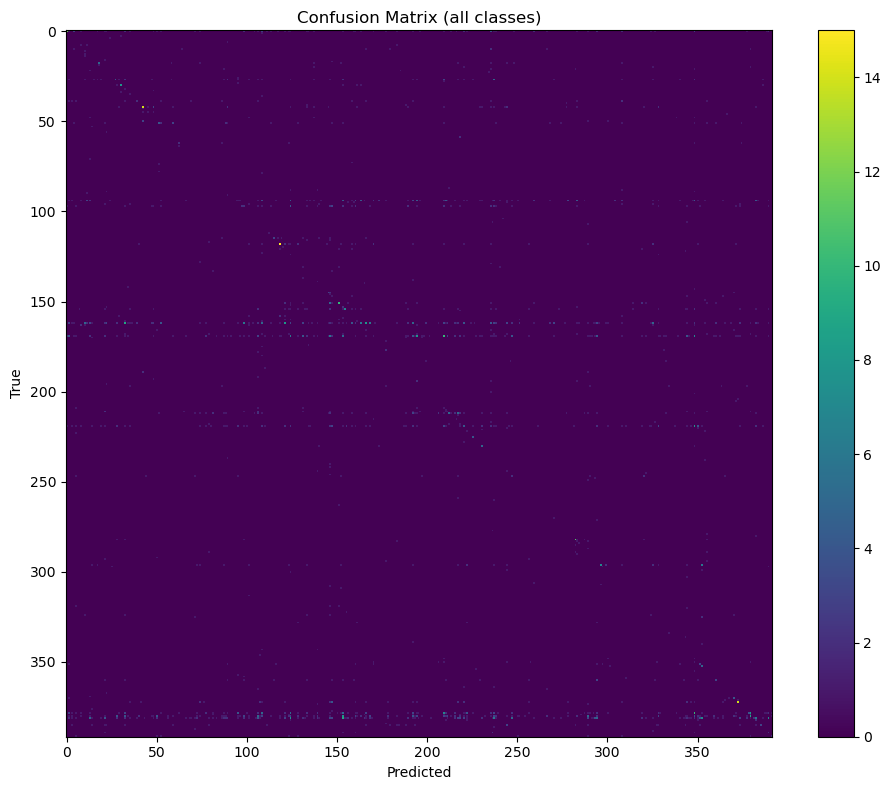

In [11]:
labels = sorted(y.unique())
cm = confusion_matrix(y_val, val_pred, labels=labels)

# Top confusion pairs (exclude diagonal)
pairs = []
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], a, b))
pairs.sort(reverse=True)

print("Top 15 confusions (count, true -> pred):")
for cnt, a, b in pairs[:15]:
    print(f"{cnt:4d}  {a} -> {b}")

# Simple plot (optional)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (all classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()

Interpretability（Every Category top n-grams）

In [12]:
# Only interpret TF-IDF feature weights (not metadata)
tfidf_vec = model.named_steps["preprocess"].named_transformers_["text"].named_steps["tfidf"]
feature_names = tfidf_vec.get_feature_names_out()

lr = model.named_steps["clf"]
classes = lr.classes_

# Find TF-IDF feature slice in the concatenated design matrix:
# In our ColumnTransformer, "text" comes first, so TF-IDF features are at the beginning.
n_tfidf = len(feature_names)
coef = lr.coef_

def show_top_features_per_class(top_k=12):
    if coef.shape[0] == 1:
        # binary
        w = coef[0][:n_tfidf]
        top_pos = np.argsort(w)[-top_k:][::-1]
        top_neg = np.argsort(w)[:top_k]
        print(f"Binary (+) class: {classes[1]}")
        print("Top positive:")
        for i in top_pos:
            print(f"  {feature_names[i]} : {w[i]:.4f}")
        print("Top negative:")
        for i in top_neg:
            print(f"  {feature_names[i]} : {w[i]:.4f}")
    else:
        for ci, c in enumerate(classes):
            w = coef[ci][:n_tfidf]
            top = np.argsort(w)[-top_k:][::-1]
            print(f"\nClass: {c}")
            for i in top:
                print(f"  {feature_names[i]} : {w[i]:.4f}")

show_top_features_per_class(top_k=10)


Class: Cognitive & Decision-Making
  prediction : 1.1759
  analysis : 0.8938
  stock : 0.7355
  prediction artificial : 0.6924
  planning : 0.6585
  intelligence ai : 0.5668
  ai stock : 0.5272
  understanding : 0.5162
  artificial : 0.4488
  artificial intelligence : 0.4438

Class: Cognitive & Decision-Making; Creativity, Expression & Identity
  interactive : 1.6631
  based artificial : 1.5251
  chatbots change : 1.5101
  design : 1.4849
  self : 1.3862
  mind : 1.3197
  consciousness ai : 1.0469
  ai develop : 1.0101
  algorithmic : 1.0020
  based : 0.9892

Class: Cognitive & Decision-Making; Creativity, Expression & Identity; Health, Safety & Risk; Society, Ethics & Culture
  experiments : 1.5052
  optimizing : 1.5035
  computational : 1.4755
  recovery : 1.4381
  modeling : 1.3933
  integrated : 1.3930
  predictive : 1.3644
  ai enhanced : 1.3007
  enhanced : 1.1683
  model : 1.0125

Class: Cognitive & Decision-Making; Creativity, Expression & Identity; Learning, Knowledge & Educa

Error Analysis Table（high-confidence errors + Export）

In [13]:
# Only interpret TF-IDF feature weights (not metadata)
tfidf_vec = model.named_steps["preprocess"].named_transformers_["text"].named_steps["tfidf"]
feature_names = tfidf_vec.get_feature_names_out()

lr = model.named_steps["clf"]
classes = lr.classes_

# Find TF-IDF feature slice in the concatenated design matrix:
# In our ColumnTransformer, "text" comes first, so TF-IDF features are at the beginning.
n_tfidf = len(feature_names)
coef = lr.coef_

def show_top_features_per_class(top_k=12):
    if coef.shape[0] == 1:
        # binary
        w = coef[0][:n_tfidf]
        top_pos = np.argsort(w)[-top_k:][::-1]
        top_neg = np.argsort(w)[:top_k]
        print(f"Binary (+) class: {classes[1]}")
        print("Top positive:")
        for i in top_pos:
            print(f"  {feature_names[i]} : {w[i]:.4f}")
        print("Top negative:")
        for i in top_neg:
            print(f"  {feature_names[i]} : {w[i]:.4f}")
    else:
        for ci, c in enumerate(classes):
            w = coef[ci][:n_tfidf]
            top = np.argsort(w)[-top_k:][::-1]
            print(f"\nClass: {c}")
            for i in top:
                print(f"  {feature_names[i]} : {w[i]:.4f}")

show_top_features_per_class(top_k=10)



Class: Cognitive & Decision-Making
  prediction : 1.1759
  analysis : 0.8938
  stock : 0.7355
  prediction artificial : 0.6924
  planning : 0.6585
  intelligence ai : 0.5668
  ai stock : 0.5272
  understanding : 0.5162
  artificial : 0.4488
  artificial intelligence : 0.4438

Class: Cognitive & Decision-Making; Creativity, Expression & Identity
  interactive : 1.6631
  based artificial : 1.5251
  chatbots change : 1.5101
  design : 1.4849
  self : 1.3862
  mind : 1.3197
  consciousness ai : 1.0469
  ai develop : 1.0101
  algorithmic : 1.0020
  based : 0.9892

Class: Cognitive & Decision-Making; Creativity, Expression & Identity; Health, Safety & Risk; Society, Ethics & Culture
  experiments : 1.5052
  optimizing : 1.5035
  computational : 1.4755
  recovery : 1.4381
  modeling : 1.3933
  integrated : 1.3930
  predictive : 1.3644
  ai enhanced : 1.3007
  enhanced : 1.1683
  model : 1.0125

Class: Cognitive & Decision-Making; Creativity, Expression & Identity; Learning, Knowledge & Educa

Save Model

In [16]:
import os, joblib

# If /mnt/data exists (cloud), use it; otherwise use local folder.
OUT_DIR = "/mnt/data" if os.path.exists("/mnt/data") else "models"
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(OUT_DIR, "tfidf_lr_baseline_with_meta.joblib")
joblib.dump(model, MODEL_PATH)
print("Saved model:", MODEL_PATH)


Saved model: models\tfidf_lr_baseline_with_meta.joblib


Inference（Top-K）

In [17]:
def predict_top_k(title: str, top_k: int = 5, meta: dict | None = None):
    """
    meta: optional dict for metadata columns, e.g.
          {"source":"CNN", "year":"2024", "quarter":"2", ...}
    """
    row = {"_text": clean_text(title)}
    meta = meta or {}

    # fill optional meta columns
    for c in cat_cols:
        row[c] = str(meta.get(c, ""))
    for c in num_cols:
        row[c] = meta.get(c, np.nan)

    X_in = pd.DataFrame([row])[["_text"] + cat_cols + num_cols]
    probs = model.predict_proba(X_in)[0]
    classes = model.named_steps["clf"].classes_
    top_idx = np.argsort(probs)[::-1][:top_k]
    return [(classes[i], float(probs[i])) for i in top_idx]

test_title = "New AI technology improves medical diagnosis accuracy"
print("Input:", test_title)
for lbl, p in predict_top_k(test_title, top_k=5):
    print(f"{lbl}: {p*100:.2f}%")


Input: New AI technology improves medical diagnosis accuracy
Sentiment (Positive / Negative Feelings); Cognitive & Decision-Making; Work, Jobs & Economy; Learning, Knowledge & Education; Society, Ethics & Culture; Technology & Interaction: 11.89%
Creativity, Expression & Identity; Health, Safety & Risk: 2.75%
Work, Jobs & Economy; Society, Ethics & Culture; Technology & Interaction: 1.93%
Human Roles; Social Interaction & Relationships; Society, Ethics & Culture; Technology & Interaction: 1.51%
Human Roles; Creativity, Expression & Identity; Learning, Knowledge & Education; Society, Ethics & Culture; Technology & Interaction: 1.51%


Insights (Themes & Sentiment)

按 source/quarter 的主题词变化”和“情绪分数趋势”，用于解释模型错分与社会叙事变化。

Sentiment by Quarter

,quarter,sentiment_score
0,2,0.181609
1,3,0.131253


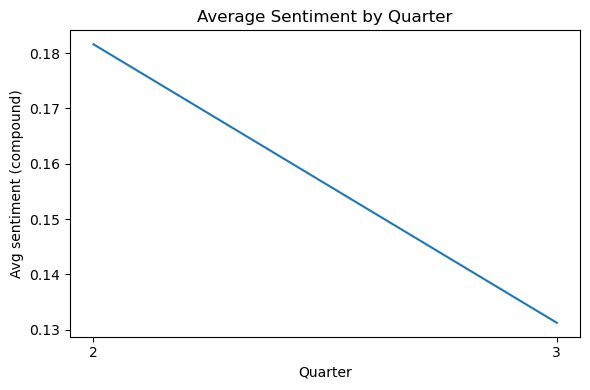

In [18]:
# If you want sentiment without heavy dependencies, use nltk VADER (already in many envs)
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

df_insight = df.copy()
df_insight["sentiment_score"] = df_insight[TEXT_COL].astype(str).apply(lambda x: sia.polarity_scores(x)["compound"])

if "quarter" in df_insight.columns:
    trend = df_insight.groupby("quarter")["sentiment_score"].mean().reset_index()
    display(trend)
    plt.figure(figsize=(6,4))
    plt.plot(trend["quarter"], trend["sentiment_score"])
    plt.title("Average Sentiment by Quarter")
    plt.xlabel("Quarter")
    plt.ylabel("Avg sentiment (compound)")
    plt.tight_layout()
    plt.show()


Topic Modeling（NMF)

In [19]:
from sklearn.decomposition import NMF

df_insight["full_text"] = df_insight[TEXT_COL].astype(str)

vec = TfidfVectorizer(max_features=2000, stop_words="english")
X_topic = vec.fit_transform(df_insight["full_text"])

nmf = NMF(n_components=8, random_state=RANDOM_SEED)
W = nmf.fit_transform(X_topic)

terms = vec.get_feature_names_out()
for k, comp in enumerate(nmf.components_):
    top = comp.argsort()[-12:][::-1]
    print(f"Topic {k}:", ", ".join(terms[i] for i in top))


Topic 0: intelligence, artificial, prediction, technology, stock, analysis, university, pdf, management, school, digital, review
Topic 1: ai, innovation, data, adoption, time, digital, government, risk, powered, technology, says, governance
Topic 2: work, ai, future, make, using, agents, ways, change, actually, tools, does, changing
Topic 3: new, ai, tool, tools, launches, university, report, study, era, law, policy, chatbot
Topic 4: job, market, ai, cuts, coming, losses, risk, won, workers, skills, jobs, says
Topic 5: using, industry, 2025, guide, complete, healthcare, ai, people, financial, services, music, retail
Topic 6: education, learning, future, higher, machine, ai, schools, students, university, classroom, pdf, medical
Topic 7: use, study, health, finds, mental, ai, chatbots, students, shows, people, generative, cases
